# Price and Mileage Outlier Analysis & Cleaning

This notebook analyzes **Price** and **Mileage** columns using context-aware outlier detection:
- **Price outliers**: Based on Brand Tier, Body Shape, and Year
- **Mileage outliers**: Based on Car Age (expected mileage per year)

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '{:,.2f}'.format(x))
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

In [27]:
# Load the data
df = pd.read_csv('cleaned_cars_v10.csv')
print(f"Total records: {len(df):,}")
print(f"\nBrand Tiers: {sorted(df['Brand_Tier'].unique())}")
print(f"Car Age Range: {df['car_age'].min()} - {df['car_age'].max()} years")

Total records: 29,826

Brand Tiers: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Car Age Range: 0 - 80 years


## 1. Overall Statistics

In [28]:
df[['Price', 'Mileage', 'car_age', 'miles_per_year']].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99])

,Price,Mileage,car_age,miles_per_year
count,"29,826.00","29,826.00","29,826.00","29,826.00"
mean,"1,179,034.60","139,366.28",11.74,"13,851.47"
std,"1,689,147.34","365,818.02",9.15,"15,188.45"
min,"5,000.00",0.00,0.00,0.00
1%,"65,000.00",0.00,1.00,0.00
5%,"145,000.00","2,000.00",2.00,300.00
25%,"370,000.00","55,000.00",5.00,"7,619.00"
50%,"660,000.00","120,000.00",9.00,"12,500.00"
75%,"1,250,000.00","195,000.00",16.00,"18,000.00"
95%,"3,950,000.00","310,000.00",29.00,"30,000.00"


---
# PRICE ANALYSIS
## 2. Price Distribution by Brand Tier

In [29]:
# Brand Tier mapping (1=Exotic, 2=Luxury, 3=Premium, 4=Economy)
tier_names = {1: 'Exotic', 2: 'Luxury', 3: 'Premium', 4: 'Economy'}
df['Tier_Name'] = df['Brand_Tier'].map(tier_names)

# Price stats by Brand Tier
price_by_tier = df.groupby('Brand_Tier')['Price'].agg(['count', 'min', 'max', 'mean', 'median', 'std'])
price_by_tier.index = price_by_tier.index.map(lambda x: f"{x}: {tier_names[x]}")
price_by_tier

,count,min,max,mean,median,std
Brand_Tier,,,,,,
1: Exotic,65,2250000,36000000,"12,309,117.22","11,000,000.00","8,252,955.56"
2: Luxury,5653,10000,45000000,"2,860,157.96","2,400,000.00","2,397,100.25"
3: Premium,19798,5000,17000000,"761,939.66","600,000.00","682,172.99"
4: Economy,4310,10000,18000000,"722,143.63","270,000.00","1,574,046.55"


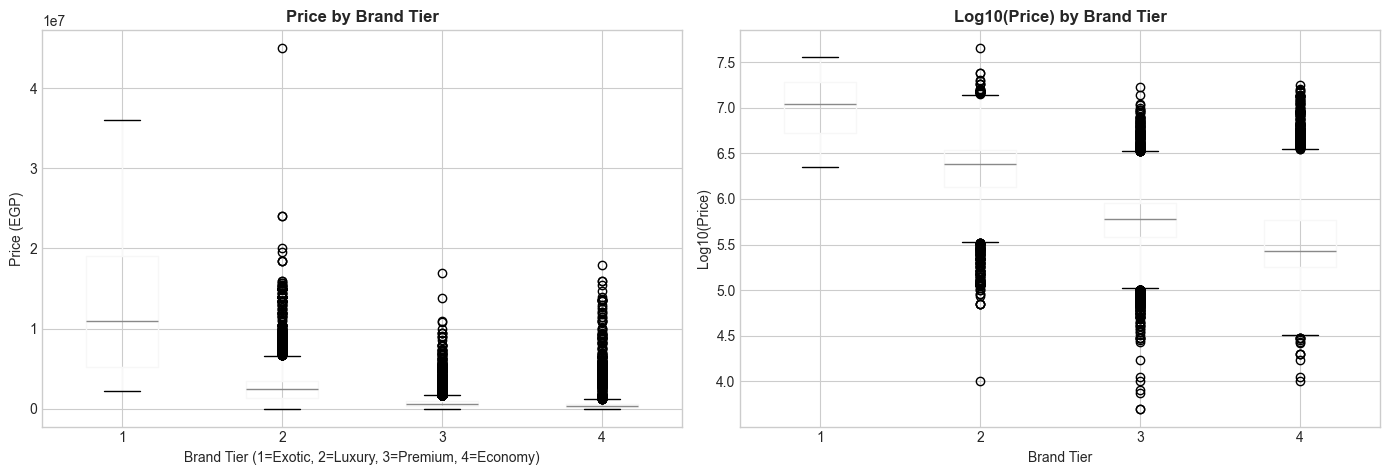

In [30]:
# Box plots by Brand Tier
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regular scale
df.boxplot(column='Price', by='Brand_Tier', ax=axes[0])
axes[0].set_title('Price by Brand Tier', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Brand Tier (1=Exotic, 2=Luxury, 3=Premium, 4=Economy)')
axes[0].set_ylabel('Price (EGP)')
plt.suptitle('')

# Log scale
df['Log_Price'] = np.log10(df['Price'])
df.boxplot(column='Log_Price', by='Brand_Tier', ax=axes[1])
axes[1].set_title('Log10(Price) by Brand Tier', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Brand Tier')
axes[1].set_ylabel('Log10(Price)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('price_by_tier.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Define Price Bounds by Brand Tier

In [31]:
def calculate_tier_price_bounds(data, tier, multiplier=3):
    """Calculate IQR-based price bounds for a specific tier"""
    tier_data = data[data['Brand_Tier'] == tier]['Price']
    Q1 = tier_data.quantile(0.25)
    Q3 = tier_data.quantile(0.75)
    IQR = Q3 - Q1
    lower = max(Q1 - multiplier * IQR, tier_data.quantile(0.01))  # Floor at 1st percentile
    upper = Q3 + multiplier * IQR
    return lower, upper

# Calculate bounds for each tier
print("PRICE BOUNDS BY BRAND TIER (IQR 3x Method):")
print("="*70)

tier_price_bounds = {}
for tier in sorted(df['Brand_Tier'].unique()):
    lower, upper = calculate_tier_price_bounds(df, tier)
    tier_data = df[df['Brand_Tier'] == tier]['Price']
    tier_price_bounds[tier] = {'lower': lower, 'upper': upper}
    
    outliers_low = (tier_data < lower).sum()
    outliers_high = (tier_data > upper).sum()
    
    print(f"\nTier {tier} ({tier_names[tier]}):")
    print(f"  Data Range: {tier_data.min():,.0f} - {tier_data.max():,.0f}")
    print(f"  Median: {tier_data.median():,.0f}")
    print(f"  Bounds: {lower:,.0f} - {upper:,.0f}")
    print(f"  Low outliers: {outliers_low} | High outliers: {outliers_high}")

PRICE BOUNDS BY BRAND TIER (IQR 3x Method):

Tier 1 (Exotic):
  Data Range: 2,250,000 - 36,000,000
  Median: 11,000,000
  Bounds: 2,250,000 - 60,250,000
  Low outliers: 0 | High outliers: 0

Tier 2 (Luxury):
  Data Range: 10,000 - 45,000,000
  Median: 2,400,000
  Bounds: 160,000 - 9,750,000
  Low outliers: 56 | High outliers: 105

Tier 3 (Premium):
  Data Range: 5,000 - 17,000,000
  Median: 600,000
  Bounds: 100,000 - 2,480,000
  Low outliers: 197 | High outliers: 451

Tier 4 (Economy):
  Data Range: 10,000 - 18,000,000
  Median: 270,000
  Bounds: 40,000 - 1,820,000
  Low outliers: 34 | High outliers: 307


In [32]:
# Manual adjustment of bounds based on domain knowledge
# These can be tuned based on market understanding

TIER_PRICE_BOUNDS = {
    1: {'min': 3000000, 'max': 50000000},   # Exotic: High-end supercars
    2: {'min': 500000,  'max': 15000000},   # Luxury: BMW, Mercedes, Audi high-end
    3: {'min': 200000,  'max': 6000000},    # Premium: Mid-range good brands
    4: {'min': 50000,   'max': 3000000},    # Economy: Budget cars
}

print("\nMANUAL PRICE BOUNDS (Recommended):")
print("="*50)
for tier, bounds in TIER_PRICE_BOUNDS.items():
    print(f"Tier {tier} ({tier_names[tier]}): {bounds['min']:,} - {bounds['max']:,} EGP")


MANUAL PRICE BOUNDS (Recommended):
Tier 1 (Exotic): 3,000,000 - 50,000,000 EGP
Tier 2 (Luxury): 500,000 - 15,000,000 EGP
Tier 3 (Premium): 200,000 - 6,000,000 EGP
Tier 4 (Economy): 50,000 - 3,000,000 EGP


## 4. Price by Body Shape (within Tiers)

In [33]:
# Price stats by Body Shape
print("Price by Body Shape:")
body_stats = df.groupby('Body Shape')['Price'].agg(['count', 'median', 'mean']).sort_values('median', ascending=False)
body_stats

Price by Body Shape:


,count,median,mean
Body Shape,,,
Convertible,157,"3,200,000.00","4,042,148.68"
Coupe,331,"2,550,000.00","3,790,604.56"
4X4,539,"1,350,000.00","3,029,983.30"
SUV,7089,"1,200,000.00","1,894,921.06"
Truck,82,"750,000.00","1,161,573.17"
Station,155,"700,000.00","881,870.97"
MPV,19,"575,000.00","771,315.79"
Sedan,17085,"550,000.00","902,073.37"
Hatchback,4091,"410,000.00","543,607.81"


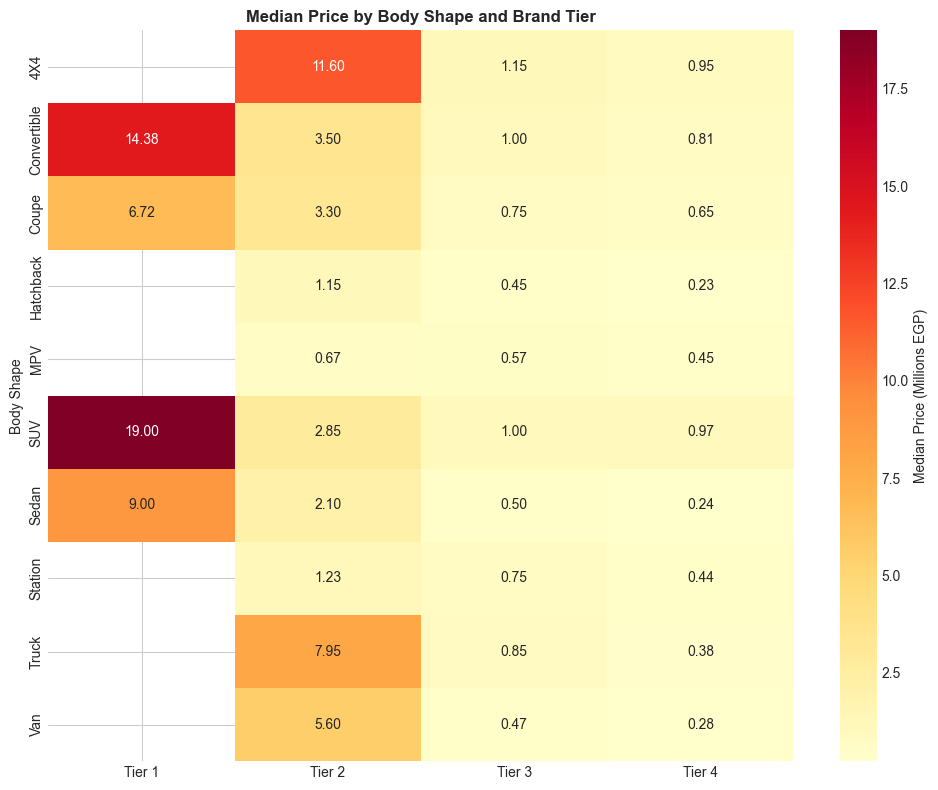

In [34]:
# Heatmap: Median Price by Tier and Body Shape
pivot = df.pivot_table(values='Price', index='Body Shape', columns='Brand_Tier', aggfunc='median')
pivot.columns = [f"Tier {c}" for c in pivot.columns]

plt.figure(figsize=(10, 8))
sns.heatmap(pivot/1000000, annot=True, fmt='.2f', cmap='YlOrRd', cbar_kws={'label': 'Median Price (Millions EGP)'})
plt.title('Median Price by Body Shape and Brand Tier', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('price_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Identify Price Outliers by Tier

In [35]:
def flag_price_outlier(row):
    """Flag if price is outside acceptable range for its tier"""
    tier = row['Brand_Tier']
    price = row['Price']
    bounds = TIER_PRICE_BOUNDS.get(tier, {'min': 0, 'max': float('inf')})
    
    if price < bounds['min']:
        return 'LOW'
    elif price > bounds['max']:
        return 'HIGH'
    return None

df['price_outlier_type'] = df.apply(flag_price_outlier, axis=1)

print("PRICE OUTLIER SUMMARY:")
print("="*50)
print(df['price_outlier_type'].value_counts(dropna=False))

price_outliers = df[df['price_outlier_type'].notna()]
print(f"\nTotal Price Outliers: {len(price_outliers):,} ({len(price_outliers)/len(df)*100:.2f}%)")

PRICE OUTLIER SUMMARY:
price_outlier_type
None    27868
LOW      1627
HIGH      331
Name: count, dtype: int64

Total Price Outliers: 1,958 (6.56%)


In [36]:
# Show price outliers by tier
print("\nPrice Outliers by Tier:")
for tier in sorted(df['Brand_Tier'].unique()):
    tier_outliers = price_outliers[price_outliers['Brand_Tier'] == tier]
    if len(tier_outliers) > 0:
        print(f"\nTier {tier} ({tier_names[tier]}): {len(tier_outliers)} outliers")
        display(tier_outliers[['Brand', 'Model', 'Year', 'Price', 'Mileage', 'price_outlier_type']].head(10))


Price Outliers by Tier:

Tier 1 (Exotic): 7 outliers


,Brand,Model,Year,Price,Mileage,price_outlier_type
14744,Maserati,Ghibli,2014,2900000,62000,LOW
14745,Maserati,GranTurismo,2010,2850000,19000,LOW
14748,Maserati,Ghibli,2014,2250000,80000,LOW
14749,Maserati,GranTurismo,2010,2850000,19000,LOW
14753,Maserati,Ghibli,2014,2250000,80000,LOW
14754,Maserati,GranTurismo,2010,2850000,19000,LOW
14755,Maserati,Ghibli,2016,2800000,30000,LOW



Tier 2 (Luxury): 273 outliers


,Brand,Model,Year,Price,Mileage,price_outlier_type
14,Alfa Romeo,146,1996,130000,300000,LOW
15,Alfa Romeo,156,2002,280000,200000,LOW
17,Alfa Romeo,156,1998,170000,250,LOW
18,Alfa Romeo,156,2000,250000,112000,LOW
29,Alfa Romeo,146,1996,130000,300000,LOW
30,Alfa Romeo,156,2000,240000,200000,LOW
31,Alfa Romeo,156,2002,280000,200000,LOW
47,Alfa Romeo,156,1999,220000,200000,LOW
91,Audi,A4,2000,420000,219000,LOW
192,Audi,A4,1995,180000,320000,LOW



Tier 3 (Premium): 1303 outliers


,Brand,Model,Year,Price,Mileage,price_outlier_type
2548,BYD,Flyer,2006,90000,110000,LOW
2558,BYD,F0,2014,190000,63000,LOW
2559,BYD,F0,2014,199000,115000,LOW
2562,BYD,F3,2010,185000,22222,LOW
2629,BYD,Flyer,2006,110000,1,LOW
2630,BYD,Flyer,2007,120000,100000,LOW
2631,BYD,Flyer,2007,120000,91000,LOW
2640,BYD,F0,2010,140000,187000,LOW
2653,BYD,Yuan,2006,165000,10000,LOW
2655,BYD,F0,2010,190000,219000,LOW



Tier 4 (Economy): 375 outliers


,Brand,Model,Year,Price,Mileage,price_outlier_type
5959,Daewoo,Nubira 1,1997,10000,650000,LOW
6687,Fiat,127,1986,40000,20,LOW
6691,Fiat,128 nova,1977,40000,100000,LOW
6695,Fiat,128 nova,1976,49000,11,LOW
6727,Fiat,127,1983,20000,5000,LOW
6729,Fiat,128,1982,30000,50000,LOW
6805,Fiat,Tipo,2020,11111,233000,LOW
6846,Fiat,Regata,1985,43000,45000,LOW
6847,Fiat,Regata,1985,40000,990000,LOW
6848,Fiat,Ritmo,1983,47000,200000,LOW


---
# MILEAGE ANALYSIS
## 6. Mileage Distribution by Car Age

In [37]:
# Mileage stats by car age groups
df['age_group'] = pd.cut(df['car_age'], bins=[0, 1, 3, 5, 10, 15, 100], 
                         labels=['0-1yr', '1-3yr', '3-5yr', '5-10yr', '10-15yr', '15+yr'])

mileage_by_age = df.groupby('age_group')['Mileage'].agg(['count', 'min', 'max', 'mean', 'median'])
mileage_by_age

C:\Users\shams\AppData\Local\Temp\ipykernel_3724\318017110.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mileage_by_age = df.groupby('age_group')['Mileage'].agg(['count', 'min', 'max', 'mean', 'median'])


,count,min,max,mean,median
age_group,,,,,
0-1yr,896,0,141000,"13,371.50","9,000.00"
1-3yr,2969,0,1190000,"30,336.24","22,000.00"
3-5yr,4749,0,1500000,"78,568.86","73,000.00"
5-10yr,7723,0,1900000,"132,559.54","125,000.00"
10-15yr,4988,0,2180000,"178,536.22","170,000.00"
15+yr,8294,0,58585858,"212,769.76","200,000.00"


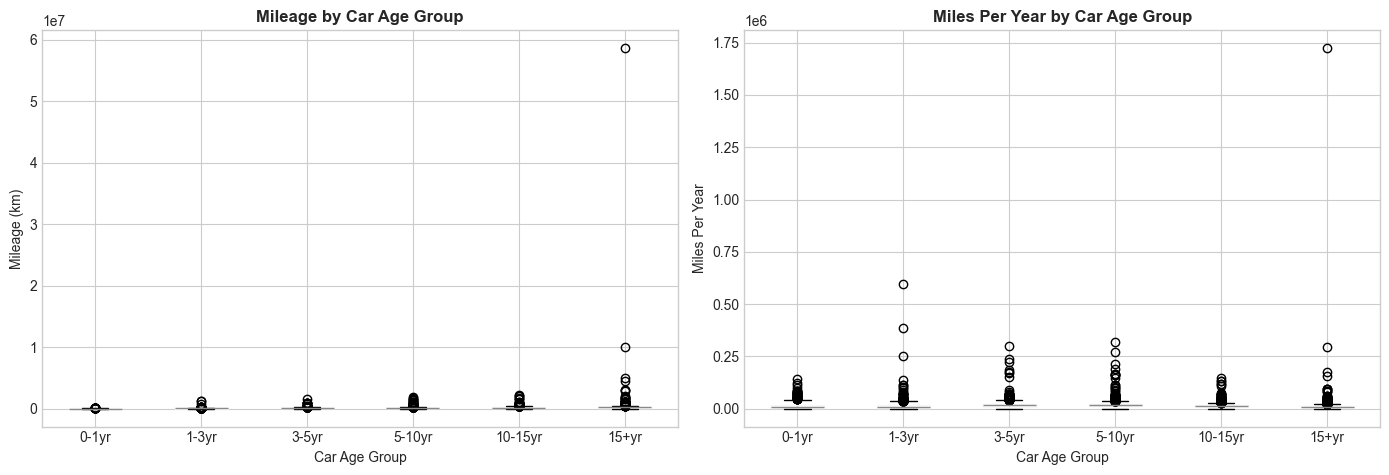

In [38]:
# Box plots by age group
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column='Mileage', by='age_group', ax=axes[0])
axes[0].set_title('Mileage by Car Age Group', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Car Age Group')
axes[0].set_ylabel('Mileage (km)')
plt.suptitle('')

df.boxplot(column='miles_per_year', by='age_group', ax=axes[1])
axes[1].set_title('Miles Per Year by Car Age Group', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Car Age Group')
axes[1].set_ylabel('Miles Per Year')
plt.suptitle('')

plt.tight_layout()
plt.savefig('mileage_by_age.png', dpi=150, bbox_inches='tight')
plt.show()

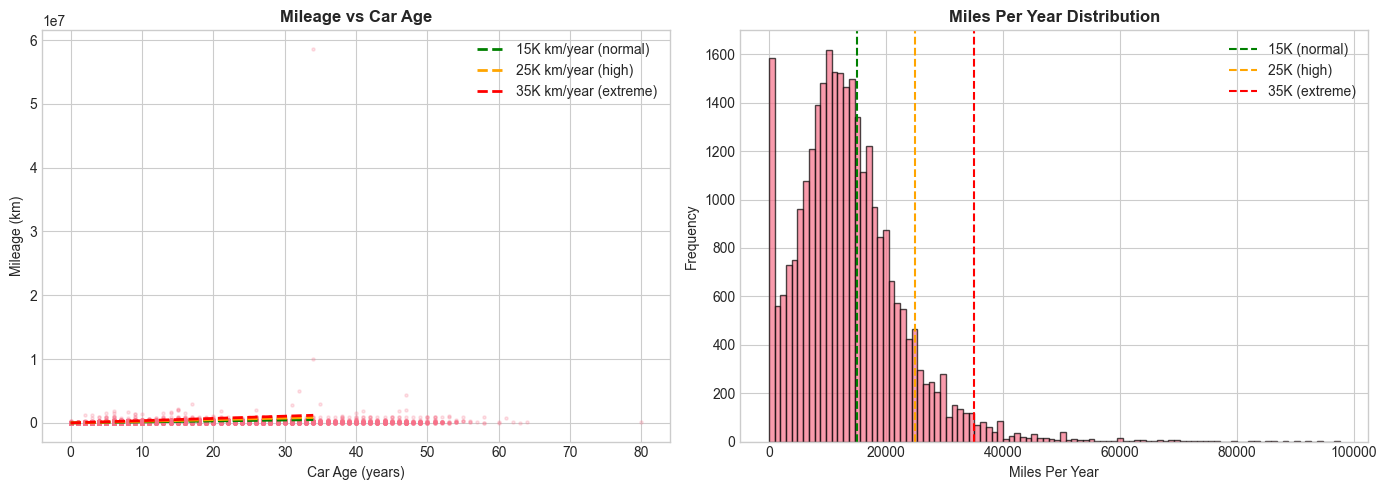

In [39]:
# Scatter: Mileage vs Car Age
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['car_age'], df['Mileage'], alpha=0.2, s=5)
axes[0].set_xlabel('Car Age (years)')
axes[0].set_ylabel('Mileage (km)')
axes[0].set_title('Mileage vs Car Age', fontsize=12, fontweight='bold')

# Add reference lines for expected mileage
ages = np.arange(0, 35)
axes[0].plot(ages, ages * 15000, 'g--', label='15K km/year (normal)', linewidth=2)
axes[0].plot(ages, ages * 25000, 'orange', linestyle='--', label='25K km/year (high)', linewidth=2)
axes[0].plot(ages, ages * 35000, 'r--', label='35K km/year (extreme)', linewidth=2)
axes[0].legend()

# Miles per year distribution
valid_mpy = df[(df['car_age'] > 0) & (df['miles_per_year'] < 100000)]['miles_per_year']
axes[1].hist(valid_mpy, bins=100, edgecolor='black', alpha=0.7)
axes[1].axvline(15000, color='green', linestyle='--', label='15K (normal)')
axes[1].axvline(25000, color='orange', linestyle='--', label='25K (high)')
axes[1].axvline(35000, color='red', linestyle='--', label='35K (extreme)')
axes[1].set_xlabel('Miles Per Year')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Miles Per Year Distribution', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('mileage_vs_age.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Define Age-Based Mileage Bounds

In [40]:
# Expected mileage per year thresholds
MILEAGE_PER_YEAR_MAX = 30000  # Max reasonable km/year
MILEAGE_PER_YEAR_MIN = 500    # Min reasonable km/year (for cars > 1 year old)

# For very new cars (0-1 year), use absolute thresholds
NEW_CAR_MAX_MILEAGE = 50000   # Max mileage for car <= 1 year old
NEW_CAR_MIN_MILEAGE = 0       # New cars can have 0 mileage

def calculate_expected_mileage_range(car_age):
    """Calculate expected mileage range based on car age"""
    if car_age <= 1:
        return NEW_CAR_MIN_MILEAGE, NEW_CAR_MAX_MILEAGE
    else:
        min_mileage = MILEAGE_PER_YEAR_MIN * car_age
        max_mileage = MILEAGE_PER_YEAR_MAX * car_age
        return min_mileage, max_mileage

# Show expected ranges
print("EXPECTED MILEAGE RANGES BY CAR AGE:")
print("="*50)
for age in [0, 1, 2, 3, 5, 7, 10, 15, 20, 25, 30]:
    min_m, max_m = calculate_expected_mileage_range(age)
    print(f"  {age:2d} years: {min_m:>7,} - {max_m:>8,} km")

EXPECTED MILEAGE RANGES BY CAR AGE:
   0 years:       0 -   50,000 km
   1 years:       0 -   50,000 km
   2 years:   1,000 -   60,000 km
   3 years:   1,500 -   90,000 km
   5 years:   2,500 -  150,000 km
   7 years:   3,500 -  210,000 km
  10 years:   5,000 -  300,000 km
  15 years:   7,500 -  450,000 km
  20 years:  10,000 -  600,000 km
  25 years:  12,500 -  750,000 km
  30 years:  15,000 -  900,000 km


In [41]:
def flag_mileage_outlier(row):
    """Flag if mileage is abnormal for the car's age"""
    age = row['car_age']
    mileage = row['Mileage']
    
    if age <= 1:
        if mileage > NEW_CAR_MAX_MILEAGE:
            return 'HIGH'
    else:
        expected_max = MILEAGE_PER_YEAR_MAX * age
        expected_min = MILEAGE_PER_YEAR_MIN * age
        
        if mileage > expected_max:
            return 'HIGH'
        elif mileage < expected_min and age >= 3:  # Only flag suspiciously low for older cars
            return 'LOW'
    
    return None

df['mileage_outlier_type'] = df.apply(flag_mileage_outlier, axis=1)

print("MILEAGE OUTLIER SUMMARY:")
print("="*50)
print(df['mileage_outlier_type'].value_counts(dropna=False))

mileage_outliers = df[df['mileage_outlier_type'].notna()]
print(f"\nTotal Mileage Outliers: {len(mileage_outliers):,} ({len(mileage_outliers)/len(df)*100:.2f}%)")

MILEAGE OUTLIER SUMMARY:
mileage_outlier_type
None    27315
HIGH     1307
LOW      1204
Name: count, dtype: int64

Total Mileage Outliers: 2,511 (8.42%)


In [42]:
# Show mileage outliers by age group
print("Mileage Outliers by Age Group:")
for grp in df['age_group'].cat.categories:
    grp_outliers = mileage_outliers[mileage_outliers['age_group'] == grp]
    if len(grp_outliers) > 0:
        print(f"\n{grp}: {len(grp_outliers)} outliers")
        display(grp_outliers[['Brand', 'Model', 'Year', 'car_age', 'Mileage', 'miles_per_year', 'mileage_outlier_type']].head(5))

Mileage Outliers by Age Group:

0-1yr: 23 outliers


,Brand,Model,Year,car_age,Mileage,miles_per_year,mileage_outlier_type
2605,BYD,F3,2025,1,80000,"80,000.00",HIGH
2637,BYD,F3,2025,1,70000,"70,000.00",HIGH
2664,BYD,Yuan,2025,1,112000,"112,000.00",HIGH
2682,BYD,F3,2025,1,58000,"58,000.00",HIGH
2712,BYD,F3,2025,1,73000,"73,000.00",HIGH



1-3yr: 198 outliers


,Brand,Model,Year,car_age,Mileage,miles_per_year,mileage_outlier_type
461,BAIC,X7,2023,3,130000,"43,333.30",HIGH
503,Bestune,T77 Pro,2023,3,750000,"250,000.00",HIGH
655,BMW,320i,2024,2,85000,"42,500.00",HIGH
1031,BMW,X7,2023,3,300,100.00,LOW
1075,BMW,X3,2023,3,51,17.00,LOW



3-5yr: 543 outliers


...

,Brand,Model,Year,car_age,Mileage,miles_per_year,mileage_outlier_type
54,Aston Martin,Rapide S,2019,7,1000,142.90,LOW
144,Audi,Q3,2016,10,350000,"35,000.00",HIGH
184,Audi,A4,2017,9,340000,"37,777.80",HIGH
187,Audi,Q2,2019,7,233000,"33,285.70",HIGH
225,Audi,A5,2019,7,230000,"32,857.10",HIGH



10-15yr: 253 outliers


,Brand,Model,Year,car_age,Mileage,miles_per_year,mileage_outlier_type
497,Bentley,Mulsanne,2011,15,1000,66.70,LOW
573,BMW,316i,2013,13,237,18.20,LOW
652,BMW,320i,2015,11,255,23.20,LOW
907,BMW,X3,2015,11,250,22.70,LOW
982,BMW,X5,2015,11,220,20.00,LOW



15+yr: 859 outliers


,Brand,Model,Year,car_age,Mileage,miles_per_year,mileage_outlier_type
17,Alfa Romeo,156,1998,28,250,8.90,LOW
93,Audi,A4,2006,20,600,30.00,LOW
319,Audi,A3,2000,26,0,0.00,LOW
574,BMW,316i,2010,16,180,11.20,LOW
590,BMW,316i,1994,32,270,8.40,LOW


---
# COMBINED ANALYSIS
## 8. Visualize Outliers

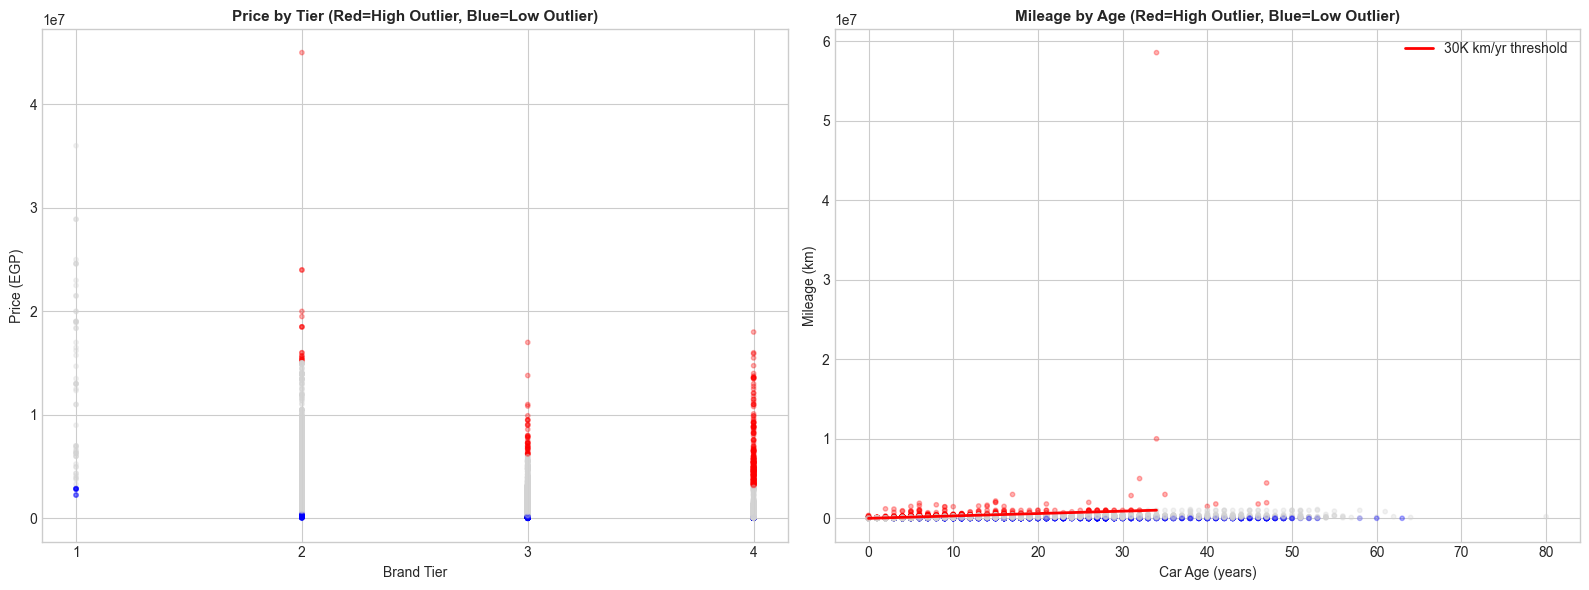

In [43]:
# Scatter plot highlighting outliers
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Price outliers by tier
colors = df['price_outlier_type'].map({'LOW': 'blue', 'HIGH': 'red'}).fillna('lightgray')
axes[0].scatter(df['Brand_Tier'], df['Price'], c=colors, alpha=0.3, s=10)
axes[0].set_xlabel('Brand Tier')
axes[0].set_ylabel('Price (EGP)')
axes[0].set_title('Price by Tier (Red=High Outlier, Blue=Low Outlier)', fontsize=11, fontweight='bold')
axes[0].set_xticks([1, 2, 3, 4])

# Mileage outliers by age
colors = df['mileage_outlier_type'].map({'LOW': 'blue', 'HIGH': 'red'}).fillna('lightgray')
axes[1].scatter(df['car_age'], df['Mileage'], c=colors, alpha=0.3, s=10)

# Add threshold lines
ages = np.arange(0, 35)
axes[1].plot(ages, ages * MILEAGE_PER_YEAR_MAX, 'r-', label=f'{MILEAGE_PER_YEAR_MAX/1000:.0f}K km/yr threshold', linewidth=2)
axes[1].set_xlabel('Car Age (years)')
axes[1].set_ylabel('Mileage (km)')
axes[1].set_title('Mileage by Age (Red=High Outlier, Blue=Low Outlier)', fontsize=11, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('outlier_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Combined Outlier Summary

In [44]:
# Flag combined outliers
df['is_price_outlier'] = df['price_outlier_type'].notna()
df['is_mileage_outlier'] = df['mileage_outlier_type'].notna()
df['is_any_outlier'] = df['is_price_outlier'] | df['is_mileage_outlier']
df['is_both_outlier'] = df['is_price_outlier'] & df['is_mileage_outlier']

print("COMBINED OUTLIER SUMMARY:")
print("="*60)
print(f"Price Outliers Only:    {(df['is_price_outlier'] & ~df['is_mileage_outlier']).sum():>6,}")
print(f"Mileage Outliers Only:  {(df['is_mileage_outlier'] & ~df['is_price_outlier']).sum():>6,}")
print(f"Both Price & Mileage:   {df['is_both_outlier'].sum():>6,}")
print(f"{'─'*60}")
print(f"Total Outliers:         {df['is_any_outlier'].sum():>6,} ({df['is_any_outlier'].sum()/len(df)*100:.2f}%)")
print(f"Clean Records:          {(~df['is_any_outlier']).sum():>6,} ({(~df['is_any_outlier']).sum()/len(df)*100:.2f}%)")

COMBINED OUTLIER SUMMARY:
Price Outliers Only:     1,612
Mileage Outliers Only:   2,165
Both Price & Mileage:      346
────────────────────────────────────────────────────────────
Total Outliers:          4,123 (13.82%)
Clean Records:          25,703 (86.18%)


In [45]:
# Cars flagged for BOTH price and mileage outliers (most suspicious)
both_outliers = df[df['is_both_outlier']]
print(f"\nCars with BOTH Price and Mileage Outliers ({len(both_outliers)}):")
if len(both_outliers) > 0:
    display(both_outliers[['Brand', 'Model', 'Year', 'Price', 'Mileage', 'car_age', 'Brand_Tier', 
                          'price_outlier_type', 'mileage_outlier_type']].head(20))


Cars with BOTH Price and Mileage Outliers (346):


,Brand,Model,Year,Price,Mileage,car_age,Brand_Tier,price_outlier_type,mileage_outlier_type
17,Alfa Romeo,156,1998,170000,250,28,2,LOW,LOW
319,Audi,A3,2000,370000,0,26,2,LOW,LOW
590,BMW,316i,1994,260000,270,32,2,LOW,LOW
1102,BMW,316i,1991,270000,500,35,2,LOW,LOW
1103,BMW,316i,1991,250000,10000,35,2,LOW,LOW
1104,BMW,316i,1994,330000,250,32,2,LOW,LOW
1112,BMW,316i,1998,450000,120,28,2,LOW,LOW
1116,BMW,318i,2000,380000,266,26,2,LOW,LOW
1190,BMW,525i,1996,360000,270,30,2,LOW,LOW
1191,BMW,525i,1998,400000,380,28,2,LOW,LOW


## 10. Apply Cleaning and Compare

In [46]:
# Clean data: remove all outliers
df_cleaned = df[~df['is_any_outlier']].copy()

print(f"CLEANING RESULTS:")
print(f"  Original Records: {len(df):,}")
print(f"  Cleaned Records:  {len(df_cleaned):,}")
print(f"  Removed:          {len(df) - len(df_cleaned):,} ({(len(df) - len(df_cleaned))/len(df)*100:.2f}%)")

CLEANING RESULTS:
  Original Records: 29,826
  Cleaned Records:  25,703
  Removed:          4,123 (13.82%)


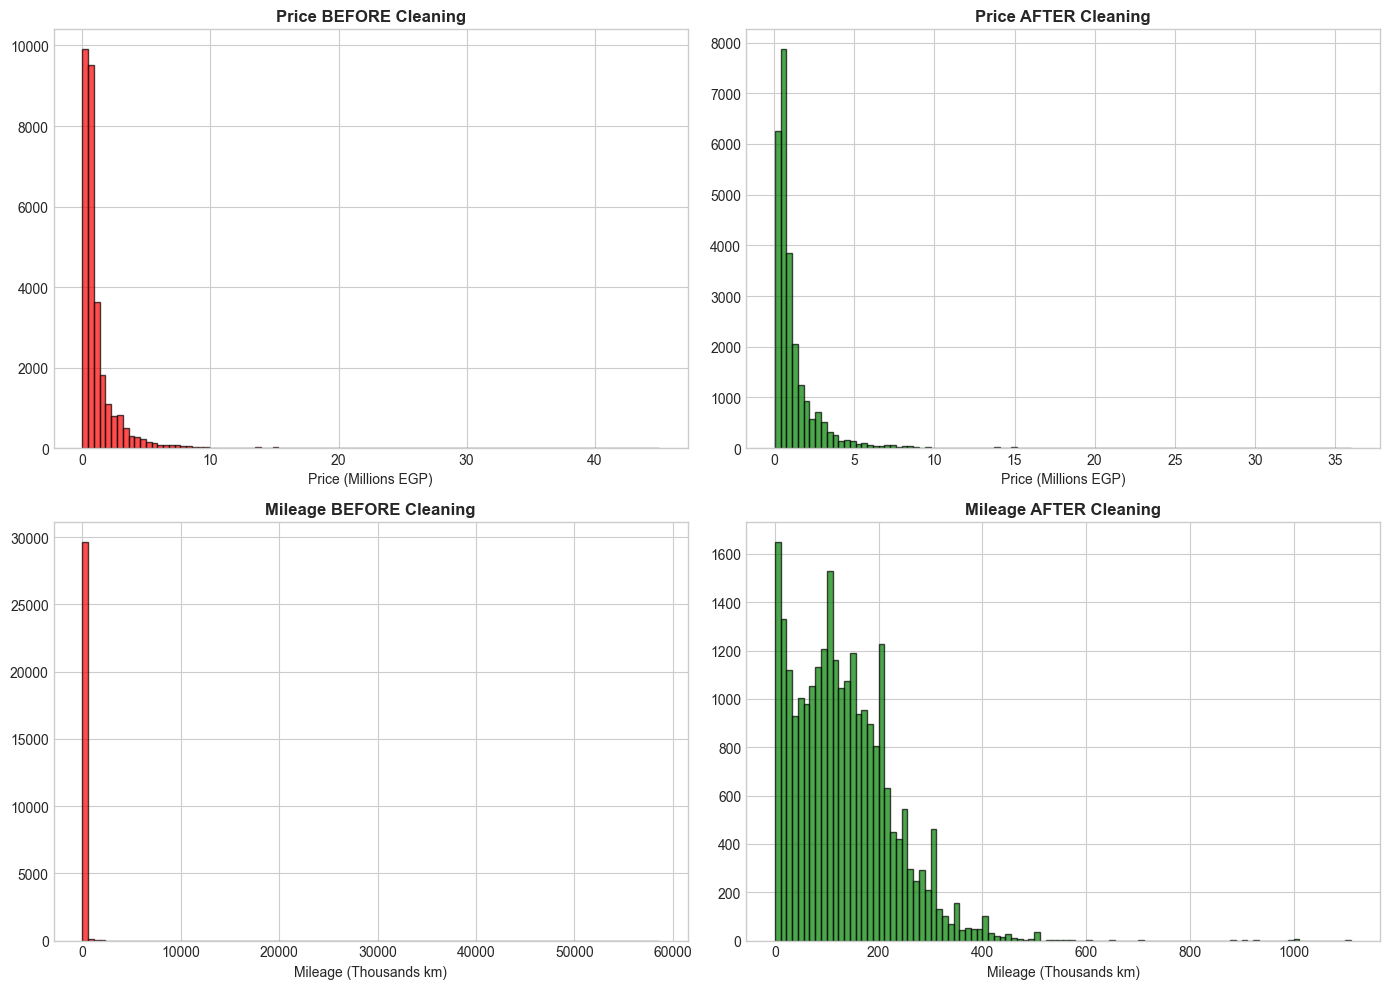

In [47]:
# Before/After distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Price
axes[0, 0].hist(df['Price']/1e6, bins=100, alpha=0.7, color='red', edgecolor='black')
axes[0, 0].set_title('Price BEFORE Cleaning', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Price (Millions EGP)')

axes[0, 1].hist(df_cleaned['Price']/1e6, bins=100, alpha=0.7, color='green', edgecolor='black')
axes[0, 1].set_title('Price AFTER Cleaning', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Price (Millions EGP)')

# Mileage
axes[1, 0].hist(df['Mileage']/1000, bins=100, alpha=0.7, color='red', edgecolor='black')
axes[1, 0].set_title('Mileage BEFORE Cleaning', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Mileage (Thousands km)')

axes[1, 1].hist(df_cleaned['Mileage']/1000, bins=100, alpha=0.7, color='green', edgecolor='black')
axes[1, 1].set_title('Mileage AFTER Cleaning', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Mileage (Thousands km)')

plt.tight_layout()
plt.savefig('before_after_cleaning.png', dpi=150, bbox_inches='tight')
plt.show()

In [48]:
# Statistics comparison
print("STATISTICS COMPARISON:")
print("="*70)

for col in ['Price', 'Mileage']:
    print(f"\n{col}:")
    print(f"  {'Metric':<10} {'Before':>15} {'After':>15} {'Change':>12}")
    print(f"  {'─'*55}")
    for stat in ['min', 'max', 'mean', 'median', 'std']:
        before = getattr(df[col], stat)()
        after = getattr(df_cleaned[col], stat)()
        pct = ((after - before) / before * 100) if before else 0
        print(f"  {stat.capitalize():<10} {before:>15,.0f} {after:>15,.0f} {pct:>11.1f}%")

STATISTICS COMPARISON:

Price:
  Metric              Before           After       Change
  ───────────────────────────────────────────────────────
  Min                  5,000          50,000       900.0%
  Max             45,000,000      36,000,000       -20.0%
  Mean             1,179,035       1,202,052         2.0%
  Median             660,000         700,000         6.1%
  Std              1,689,147       1,568,912        -7.1%

Mileage:
  Metric              Before           After       Change
  ───────────────────────────────────────────────────────
  Min                      0               0         0.0%
  Max             58,585,858       1,111,111       -98.1%
  Mean               139,366         131,877        -5.4%
  Median             120,000         120,000         0.0%
  Std                365,818          93,165       -74.5%


## 11. Save Cleaned Data

In [49]:
# Drop temporary columns before saving
cols_to_drop = ['Log_Price', 'Tier_Name', 'age_group', 'price_outlier_type', 'mileage_outlier_type',
                'is_price_outlier', 'is_mileage_outlier', 'is_any_outlier', 'is_both_outlier']
df_export = df_cleaned.drop(columns=[c for c in cols_to_drop if c in df_cleaned.columns])

output_file = 'cleaned_cars_v11.csv'
df_export.to_csv(output_file, index=False)

print(f"Saved cleaned data to: {output_file}")
print(f"Final record count: {len(df_export):,}")

Saved cleaned data to: cleaned_cars_v11.csv
Final record count: 25,703


## 12. Tuning Parameters Summary

In [50]:
print("="*70)
print("CLEANING PARAMETERS USED:")
print("="*70)

print("\nPRICE BOUNDS BY BRAND TIER:")
for tier, bounds in TIER_PRICE_BOUNDS.items():
    print(f"  Tier {tier} ({tier_names[tier]:8s}): {bounds['min']:>10,} - {bounds['max']:>12,} EGP")

print(f"\nMILEAGE BOUNDS (Age-Based):")
print(f"  Max km/year threshold: {MILEAGE_PER_YEAR_MAX:,} km/year")
print(f"  Min km/year threshold: {MILEAGE_PER_YEAR_MIN:,} km/year (for cars > 3 years)")
print(f"  New car (≤1 yr) max:   {NEW_CAR_MAX_MILEAGE:,} km")

print(f"\nTo adjust these thresholds, modify:")
print(f"  - TIER_PRICE_BOUNDS dictionary")
print(f"  - MILEAGE_PER_YEAR_MAX, MILEAGE_PER_YEAR_MIN, NEW_CAR_MAX_MILEAGE")

CLEANING PARAMETERS USED:

PRICE BOUNDS BY BRAND TIER:
  Tier 1 (Exotic  ):  3,000,000 -   50,000,000 EGP
  Tier 2 (Luxury  ):    500,000 -   15,000,000 EGP
  Tier 3 (Premium ):    200,000 -    6,000,000 EGP
  Tier 4 (Economy ):     50,000 -    3,000,000 EGP

MILEAGE BOUNDS (Age-Based):
  Max km/year threshold: 30,000 km/year
  Min km/year threshold: 500 km/year (for cars > 3 years)
  New car (≤1 yr) max:   50,000 km

To adjust these thresholds, modify:
  - TIER_PRICE_BOUNDS dictionary
  - MILEAGE_PER_YEAR_MAX, MILEAGE_PER_YEAR_MIN, NEW_CAR_MAX_MILEAGE
